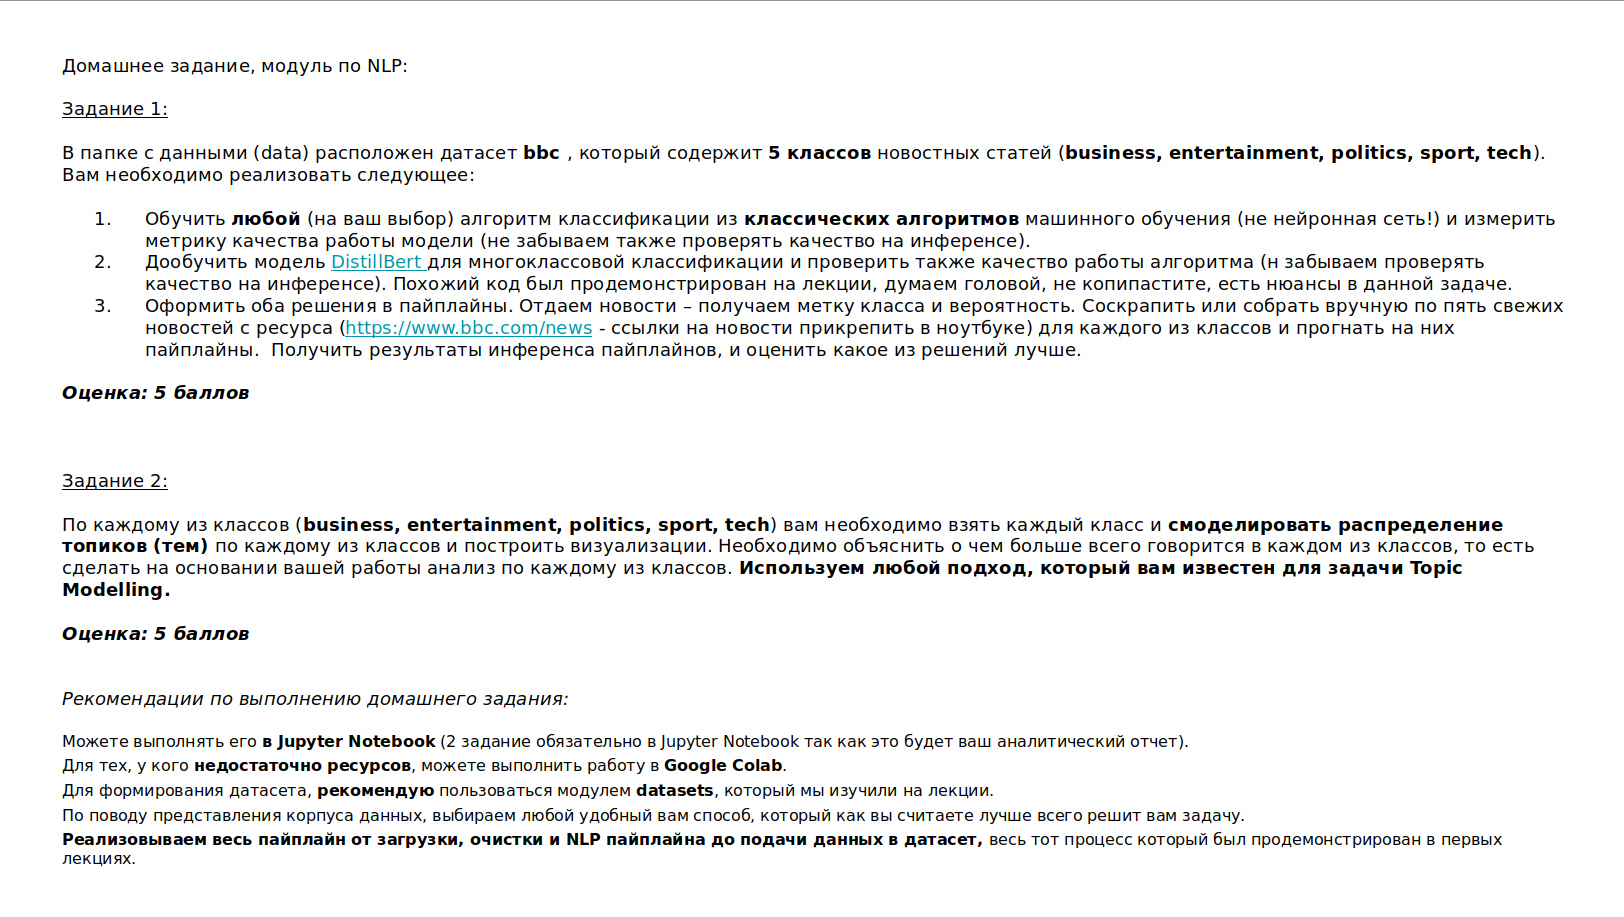

In [1]:
import pandas as pd
import numpy as np
import re
import string

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, classification_report
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression

import nltk
nltk.download('stopwords')
from nltk.corpus import stopwords

from transformers import DistilBertTokenizerFast, DistilBertForSequenceClassification, Trainer, TrainingArguments
from datasets import Dataset

[nltk_data] Downloading package stopwords to
[nltk_data]     /home/zybliuk/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
/home/zybliuk/projects/course_modules/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
df = pd.read_csv('bbc.csv')

print("Classes:")
df['category'].value_counts()

Classes:


category
sport            511
business         510
politics         417
tech             401
entertainment    386
Name: count, dtype: int64

In [3]:
stop_words = set(stopwords.words('english'))

def clean_text(text):
    text = text.lower()
    text = re.sub(r'\n', ' ', text)
    text = re.sub(r'\d+', '', text)
    text = text.translate(str.maketrans('', '', string.punctuation))
    text = ' '.join([w for w in text.split() if w not in stop_words])
    
    return text

df['clean_text'] = df['text'].apply(clean_text)

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    df['clean_text'],
    df['category'],
    test_size=0.2,
    random_state=42,
    stratify=df['category']
)

In [5]:
classic_pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(max_features=5000)),
    ('clf', LogisticRegression(max_iter=200))
])

classic_pipeline.fit(X_train, y_train)

,steps,"[('tfidf', ...), ('clf', ...)]"
,transform_input,None
,memory,None
,verbose,False
,input,'content'
,encoding,'utf-8'
,decode_error,'strict'
,strip_accents,None
,lowercase,True
,preprocessor,None
,tokenizer,None


In [6]:

y_pred = classic_pipeline.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
classification_report(y_test, y_pred)

Accuracy: 0.9842696629213483


'               precision    recall  f1-score   support\n\n     business       0.98      0.97      0.98       102\nentertainment       0.97      0.99      0.98        77\n     politics       0.98      0.99      0.98        84\n        sport       1.00      1.00      1.00       102\n         tech       0.99      0.97      0.98        80\n\n     accuracy                           0.98       445\n    macro avg       0.98      0.98      0.98       445\n weighted avg       0.98      0.98      0.98       445\n'

In [7]:
def predict_classic(text):
    probs = classic_pipeline.predict_proba([text])[0]
    label = classic_pipeline.predict([text])[0]
    
    return label, probs

In [8]:
labels = df['category'].unique()

label2id = {l: i for i, l in enumerate(labels)}
id2label = {i: l for l, i in label2id.items()}

df['label'] = df['category'].map(label2id)

In [9]:
dataset = Dataset.from_pandas(df[['clean_text', 'label']])
dataset = dataset.train_test_split(test_size=0.2)

In [10]:
tokenizer = DistilBertTokenizerFast.from_pretrained('distilbert-base-uncased')

def tokenize(batch):
    return tokenizer(batch['clean_text'], padding=True, truncation=True)

dataset = dataset.map(tokenize, batched=True)

dataset.set_format(
    type='torch',
    columns=['input_ids', 'attention_mask', 'label']
)

Map: 100%|██████████| 445/445 [00:00<00:00, 6707.17 examples/s]


In [11]:
model = DistilBertForSequenceClassification.from_pretrained(
    'distilbert-base-uncased',
    num_labels=len(labels)
)

model.config.id2label = id2label
model.config.label2id = label2id


Loading weights: 100%|██████████| 100/100 [00:00<00:00, 6479.29it/s]
DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.weight  | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [12]:
training_args = TrainingArguments(
    output_dir='./results',
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    num_train_epochs=3,
    logging_steps=50
)

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=1)
    
    return {"accuracy": accuracy_score(labels, preds)}

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=dataset['train'],
    eval_dataset=dataset['test'],
    compute_metrics=compute_metrics
)

In [13]:
trainer.train()

Step,Training Loss
50,0.942559
100,0.150442
150,0.134436
200,0.132487
250,0.076093
300,0.063324
350,0.045610
400,0.046042
450,0.022115
500,0.019483


Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  2.64it/s]


TrainOutput(global_step=669, training_loss=0.1253569135066506, metrics={'train_runtime': 186.6931, 'train_samples_per_second': 28.603, 'train_steps_per_second': 3.583, 'total_flos': 707413753958400.0, 'train_loss': 0.1253569135066506, 'epoch': 3.0})

In [14]:
predictions = trainer.predict(dataset['test'])

preds = np.argmax(predictions.predictions, axis=1)
labels_true = predictions.label_ids

print("Accuracy:", accuracy_score(labels_true, preds))
classification_report(labels_true, preds)

Accuracy: 0.9820224719101124


'              precision    recall  f1-score   support\n\n           0       0.94      1.00      0.97        75\n           1       1.00      0.94      0.97       106\n           2       0.99      1.00      1.00       109\n           3       1.00      1.00      1.00        72\n           4       0.98      0.98      0.98        83\n\n    accuracy                           0.98       445\n   macro avg       0.98      0.98      0.98       445\nweighted avg       0.98      0.98      0.98       445\n'

In [15]:
from transformers import pipeline

def predict_classic_pipeline(text):
    cleaned = clean_text(text)
    probs = classic_pipeline.predict_proba([cleaned])[0]
    best_idx = np.argmax(probs)
    predicted_class = classic_pipeline.classes_[best_idx]
    best_prob = probs[best_idx]
    
    return predicted_class, best_prob

In [16]:
bert_pipe = pipeline(
    "text-classification", 
    model=model, 
    tokenizer=tokenizer, 
    device=model.device
)

def predict_bert_pipeline(text):
    result = bert_pipe(text, truncation=True, max_length=512)[0]
    
    return result['label'], result['score']

df_fresh = pd.read_csv('new_bbc.csv')
fresh_bbc_news = df_fresh.to_dict('records')

In [17]:
correct_classic = 0
correct_bert = 0

for i, news in enumerate(fresh_bbc_news, 1):
    text = news['text']
    true_label = news['true_label']
    
    classic_label, classic_prob = predict_classic_pipeline(text)
    bert_label, bert_prob = predict_bert_pipeline(text)
    
    if classic_label == true_label: correct_classic += 1
    if bert_label == true_label: correct_bert += 1
    
    print(f"\n[{i}/25]: {true_label.upper()}")
    print(f"URL: {news['url']}")
    print(f"Txt: {text[:80]}...")
    print(f"Classic ML : {classic_label:<15} (Confidence: {classic_prob*100:.1f}%)")
    print(f"DistilBERT : {bert_label:<15} (Confidence: {bert_prob*100:.1f}%)")

total = len(fresh_bbc_news)
print(f"Classic ML: {correct_classic}/{total} ({(correct_classic/total)*100:.1f}%)")
print(f"DistilBERT: {correct_bert}/{total} ({(correct_bert/total)*100:.1f}%)")


[1/25]: SPORT
URL: https://www.bbc.co.uk/sport/boxing/articles/c4gvdy89pn7o
Txt: """""""Fury unlikely to be world champion again - Wardley 01:48 Media caption  '...
Classic ML : sport           (Confidence: 53.4%)
DistilBERT : sport           (Confidence: 99.8%)

[2/25]: SPORT
URL: https://www.bbc.co.uk/sport/football/articles/c75k1d6g2xpo
Txt: """""""The Red Arrows are world renowned as daredevils of the sky an elite Royal...
Classic ML : sport           (Confidence: 83.9%)
DistilBERT : sport           (Confidence: 99.8%)

[3/25]: SPORT
URL: https://www.bbc.co.uk/sport/rugby-union/articles/c78l3jx09l7o
Txt: """""""Glasgow Warriors back row Emily Coubrough will make her Scotland debut in...
Classic ML : sport           (Confidence: 85.0%)
DistilBERT : sport           (Confidence: 99.9%)

[4/25]: SPORT
URL: https://www.bbc.co.uk/sport/football/articles/cvg3kxy221xo
Txt: """""""Clubs at risk of relegation tend to hire pragmatic coaches.  But that is ...
Classic ML : sport           (Con

You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset



[9/25]: BUSINESS
URL: https://www.bbc.com/news/articles/c5ywpv1d4geo
Txt: """""""Why fuel and food prices could still be affected for months 1 day ago Jem...
Classic ML : business        (Confidence: 81.3%)
DistilBERT : business        (Confidence: 99.9%)

[10/25]: BUSINESS
URL: https://www.bbc.com/news/articles/ckge155rz10o
Txt: """""""The construction boss who built a new life after three years in prison 19...
Classic ML : business        (Confidence: 29.6%)
DistilBERT : business        (Confidence: 58.7%)

[11/25]: TECH
URL: https://www.bbc.com/news/articles/c3ewe7v7gpgo
Txt: """Amazon's Alexa has had an AI upgrade. Now she's got more to say 19 March 2026...
Classic ML : tech            (Confidence: 64.7%)
DistilBERT : tech            (Confidence: 99.8%)

[12/25]: TECH
URL: https://www.bbc.com/news/articles/clyg4wx6nxgo
Txt: """AI toys for children misread emotions and respond inappropriately researchers...
Classic ML : politics        (Confidence: 30.5%)
DistilBERT : tech         

Результаты вышли одинаковыми, но у DistilBERT уверенность сильно выше. Часть новостей, что я выбрал находиться на смеси жанров и там даже мне сложно было бы определить жанр. Например, новость, что я выбрал в разделе бизнеса касалась Амурского пролива и как это влияет на экономику, но так как тут много политического терминов и сама тебя политизирована, обе модели определили ее к политике, в принципе я согласен с ними

ЗАДАНИЕ 2

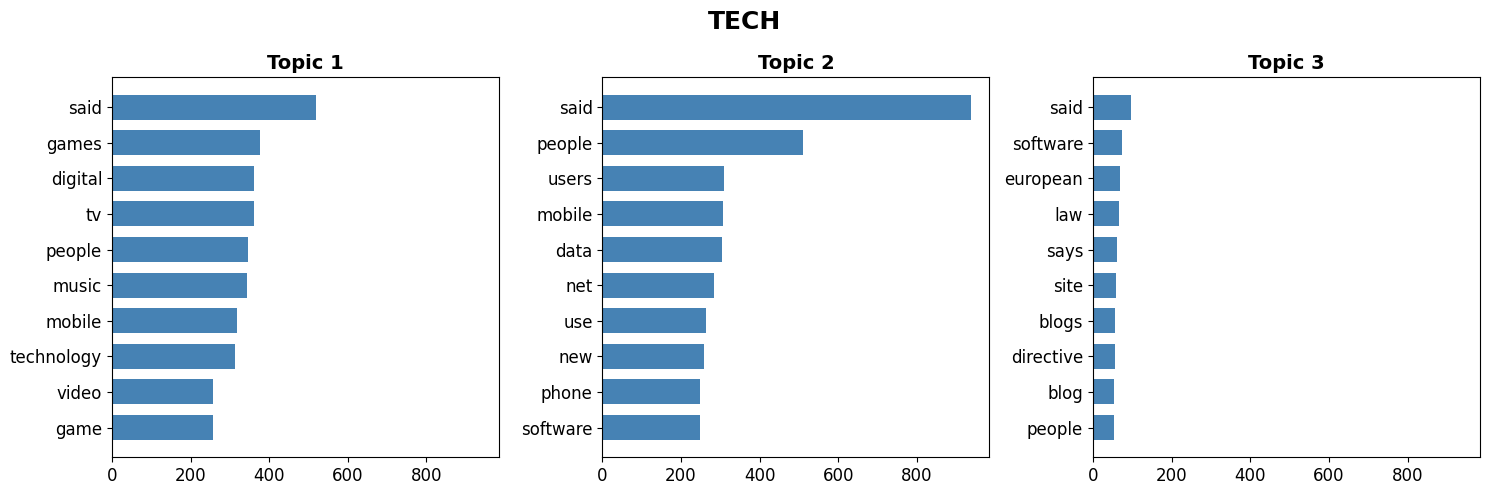

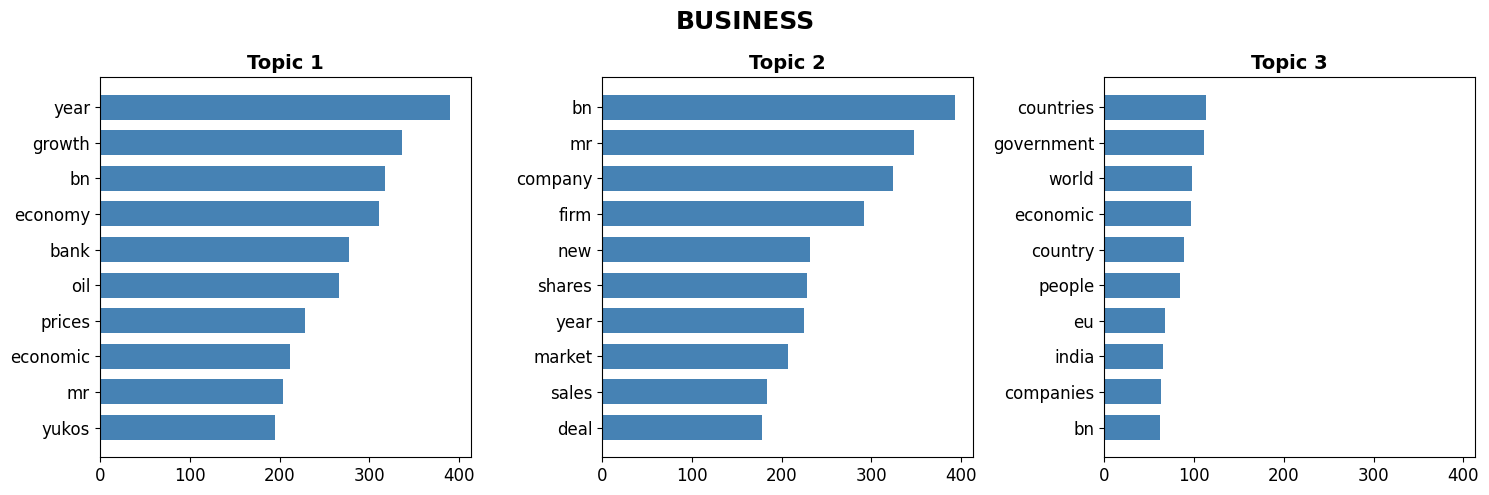

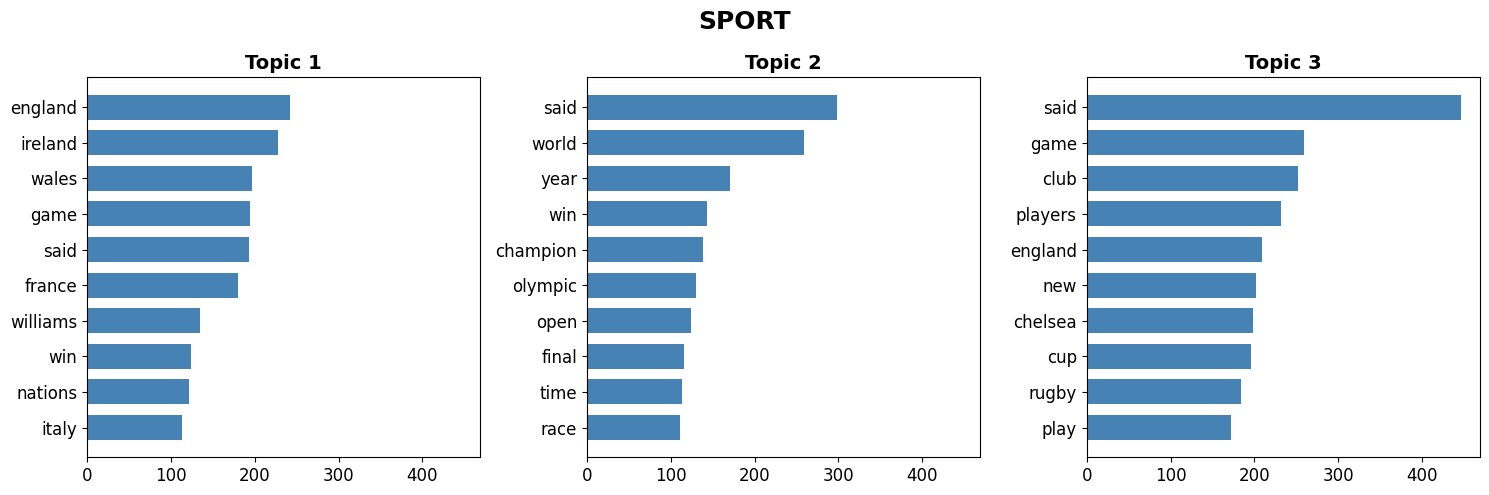

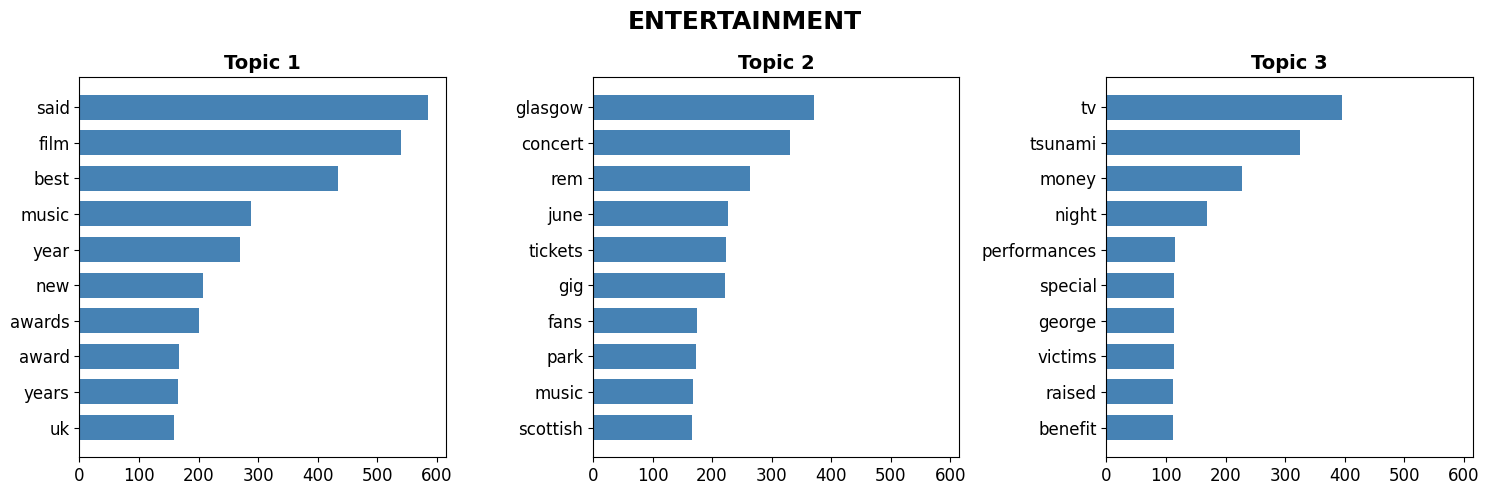

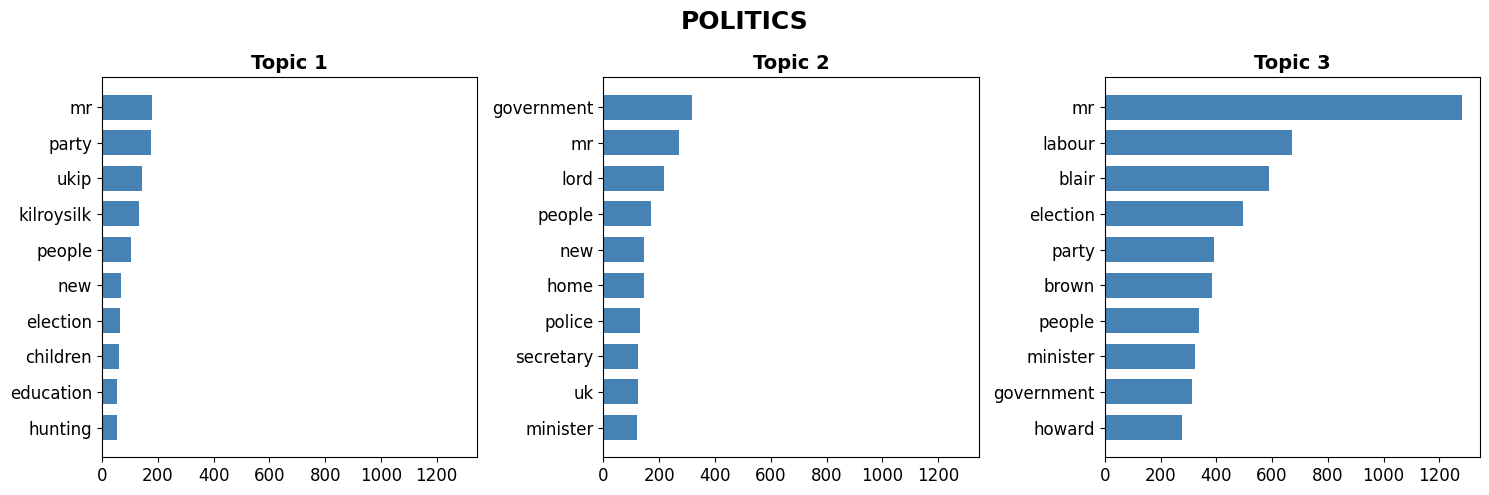

In [18]:

import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation

n_topics = 3
n_top_words = 10

def plot_top_words(model, feature_names, n_top_words, class_name):
    fig, axes = plt.subplots(1, n_topics, figsize=(15, 5), sharex=True)
    axes = axes.flatten()
    for topic_idx, topic in enumerate(model.components_):
        top_features_ind = topic.argsort()[: -n_top_words - 1 : -1]
        top_features = [feature_names[i] for i in top_features_ind]
        weights = topic[top_features_ind]

        ax = axes[topic_idx]
        ax.barh(top_features, weights, height=0.7, color='steelblue')
        ax.set_title(f"Topic {topic_idx + 1}", fontdict={"fontsize": 14, "fontweight": "bold"})
        ax.invert_yaxis()
        ax.tick_params(axis="both", which="major", labelsize=12)
        
    plt.suptitle(f"{class_name.upper()}", fontsize=18, fontweight='bold')
    plt.tight_layout()
    plt.show()

categories = df['category'].unique()

for category in categories:
    docs = df[df['category'] == category]['clean_text']
    
    vectorizer = CountVectorizer(max_df=0.9, min_df=5, stop_words='english')
    tf = vectorizer.fit_transform(docs)
    tf_feature_names = vectorizer.get_feature_names_out()
    
    lda = LatentDirichletAllocation(
        n_components=n_topics, 
        max_iter=15, 
        learning_method='online', 
        random_state=42
    )
    lda.fit(tf)
    
    plot_top_words(lda, tf_feature_names, n_top_words, category)

В классах TECH и BUSINESS алгорим выделил специфические подтемы. В технологиях сформировались топики вокруг цифровых медиа (games, tv, music) , мобильной связи и данных (users, mobile, net, phone) , а также правового регулирования (software, european, law, directive). Бизнес-категория разделена на макроэкономику с фокусом на энергетику (growth, economy, oil, yukos) , корпоративные финансы (shares, market, deal) и глобальную торговлю (countries, government, eu, india).

Разделы SPORT и ENTERTAINMENT демонстрируют событийную кластеризацию. Спорт четко распался на Кубок шести наций по регби (england, ireland, wales, france, italy) , международные турниры (champion, olympic, race) и клубные соревнования (club, chelsea, cup). В сфере развлечений выделяются премии (film, awards, best) , а также топики, связанные с благотворительными концертами в помощь жертвам цунами (tsunami, concert, performances) и локальными шотландскими сборами (glasgow, scottish, benefit).

В классе POLITICS модель уловила повестку и ключевые фигуры британской политики. Выделяется топик, связанный с локальными партиями и выборами (ukip, kilroysilk, election) , а также тема внутренней политики и регулирования (police, home, secretary, hunting). Третий топик строго сфокусирован на лидерах крупнейших партий (labour, blair, brown, howard).